In [1]:
import json
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_name = "alexdellabruna/gpt-oss-20b-qlora"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, output_hidden_states=True, output_attentions=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

Fetching 3 files: 100%|██████████| 3/3 [01:01<00:00, 20.38s/it]
[transformers] The following generation flags are not valid and may be ignored: ['output_attentions', 'output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 411/411 [00:00<00:00, 4168.26it/s]


GptOssForCausalLM(
  (model): GptOssModel(
    (embed_tokens): Embedding(201088, 2880, padding_idx=199999)
    (layers): ModuleList(
      (0-23): 24 x GptOssDecoderLayer(
        (self_attn): GptOssAttention(
          (q_proj): Linear(in_features=2880, out_features=4096, bias=True)
          (k_proj): Linear(in_features=2880, out_features=512, bias=True)
          (v_proj): Linear(in_features=2880, out_features=512, bias=True)
          (o_proj): Linear(in_features=4096, out_features=2880, bias=True)
        )
        (mlp): GptOssMLP(
          (router): GptOssTopKRouter()
          (experts): GptOssExperts()
        )
        (input_layernorm): GptOssRMSNorm((2880,), eps=1e-05)
        (post_attention_layernorm): GptOssRMSNorm((2880,), eps=1e-05)
      )
    )
    (norm): GptOssRMSNorm((2880,), eps=1e-05)
    (rotary_emb): GptOssRotaryEmbedding()
  )
  (lm_head): Linear(in_features=2880, out_features=201088, bias=False)
)

In [3]:
def draw_per_layer_heatmap(hidden_states,out_f_name):

    num_layers = len(hidden_states)
    seq_len = hidden_states[0].shape[1]

    fig, axes = plt.subplots(
        nrows=num_layers,
        ncols=1,
        figsize=(12, 2 * num_layers),
        sharex=True
    )

    for i, ax in enumerate(axes):
        hs = hidden_states[i][0].detach().float().cpu().numpy()  # (seq_len, hidden_dim)
        sns.heatmap(
            hs,
            cmap="viridis",
            cbar=False,
            ax=ax
        )
        ax.set_ylabel(f"L{i}")

    axes[-1].set_xlabel("Hidden dimension")
    plt.suptitle("Hidden states across all layers", y=1.02)
    plt.tight_layout()
    plt.savefig(f"./{out_f_name}.png")
    plt.show()

Layers: 25
torch.Size([1, 13, 2880])
[-0.017625605918339646, 0.031954972764365513, 0.06564395448081542, 0.08136156685331938, 0.09978253128182187, 0.15380563165387556, 0.18224067035903174, -0.9618862608558922, -0.9422528650006669, -0.8933766617734268, -0.9348292945796545, -0.751499078212638, -0.7294455634223078, -0.5963020422519901, -0.560050977397156, -0.6635472745977065, -0.7356234036959026, -1.1978184365818652, -0.06697838938134304, 0.17690883538661842, 0.9628138615534809, 1.4952854775974889, 1.796552922175487, 2.0831039037459784, 0.06204264286236935]


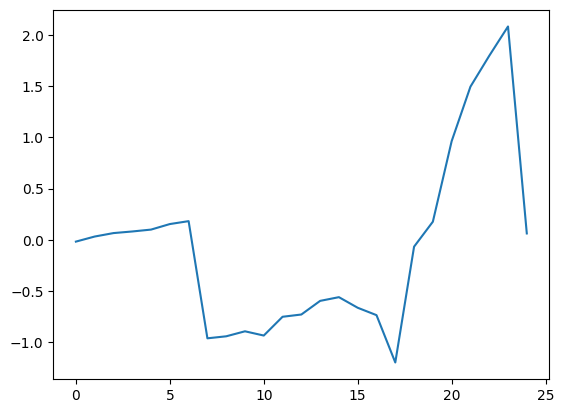

Layers: 25
torch.Size([1, 17, 2880])
[-0.012864097387657874, 0.03646664245455876, 0.06502290925169256, 0.09001685996460754, 0.08255159527647775, 0.12461881949231542, 0.1448047151752538, -0.7097936443253904, -0.703941128300686, -0.6286321727278918, -0.700273940142468, -0.530028518975953, -0.6450860565783901, -0.5753563376033906, -0.5599846335018329, -0.7515451568404086, -1.003544128019052, -1.3663173102085828, -0.7185756309359732, -0.5730123881421041, -0.5630906048942997, -0.7683536305147097, -0.9472628923802534, -0.9798985300500368, 0.01350807567047934]


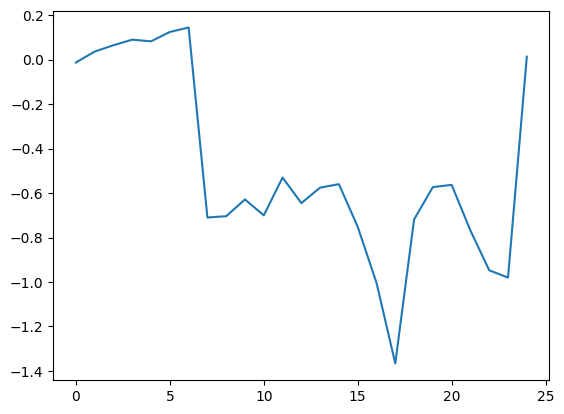

Layers: 25
torch.Size([1, 13, 2880])
[0.008108639156517517, 0.05209889330415657, 0.08570178716610613, 0.11693221728007029, 0.12112369048289799, 0.1815958479530803, 0.22682024393326233, -0.9029822781554576, -0.8767947042090228, -0.8450503487872362, -0.8378439291929676, -0.5994061983548624, -0.5712641658945833, -0.5268881512503443, -0.5495334070971752, -0.4435956971258051, -0.558697183723119, -0.6745020157251613, 0.33959217560596916, 0.9885802440154295, 1.6359601925580831, 2.538173577724363, 3.166529572315722, 2.965136614416388, 0.07679292773589211]


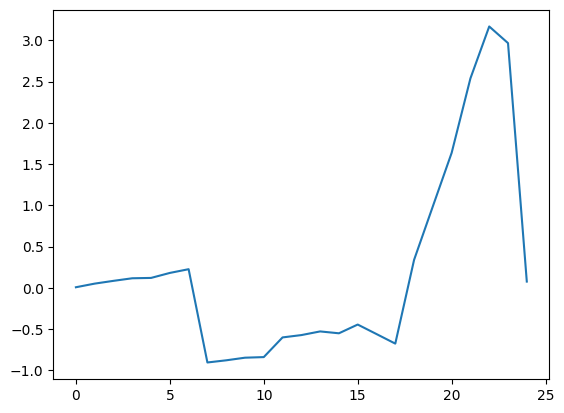

Layers: 25
torch.Size([1, 19, 2880])
[-0.027885243987013492, 0.025403851514671595, 0.05003241656119289, 0.0879750848513603, 0.11518072803118136, 0.18577625598126818, 0.22756580665097723, -0.4958631058185649, -0.4756980851379797, -0.38054693121658956, -0.3377329329998203, -0.10873917250604898, -0.09384068717733472, 0.04299942819696929, 0.06861264412863337, 0.050427085474906326, -0.10375145806206877, -0.21335768002515323, 0.39858348467196497, 0.5525899786698195, -0.07195370322779808, -0.2977757861042551, 0.0032917580409340206, -0.18236590826023608, 0.03291036504053944]


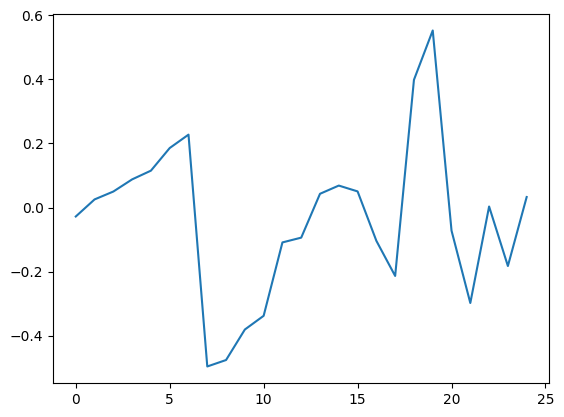

Layers: 25
torch.Size([1, 15, 2880])
[-0.003361362775408288, 0.047384022959956106, 0.06799449072943799, 0.10988443374633793, 0.11984616738778532, 0.19389819675021622, 0.23467946370442683, -0.720555756180379, -0.699585673014329, -0.5958850125913236, -0.5842939475730664, -0.28783201994719926, -0.42182182594581913, -0.34729237874349195, -0.3743856133355079, -0.44813009756582484, -0.5859546350549651, -1.0401612288863478, 0.24321632667824045, 0.7007775878906216, 0.7744932273582206, 1.5794728823061135, 1.8549195240162237, 2.0905724645544153, 0.09478267784471715]


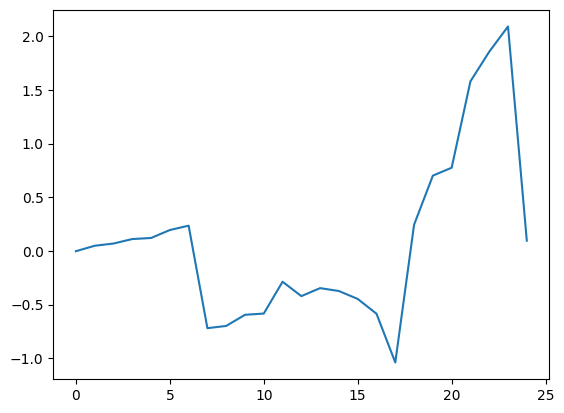

Layers: 25
torch.Size([1, 12, 2880])
[-0.012789172065121947, 0.03383949685979763, 0.060053151625174064, 0.09978141872971114, 0.11355293238604533, 0.12446247074339134, 0.18648112968162275, -1.0189320317021193, -1.0168019753915294, -0.9535201390584308, -0.8976495107014731, -0.6479725166603276, -0.69713332564743, -0.5783117223668957, -0.6575802555790664, -0.7821412828233644, -0.9735693472402777, -1.3485855667679263, -0.3201364022714114, 0.14397306089048112, 0.521923376012723, 0.8863761619285322, 1.340655602349177, 1.2679888689959407, 0.056686271340758876]


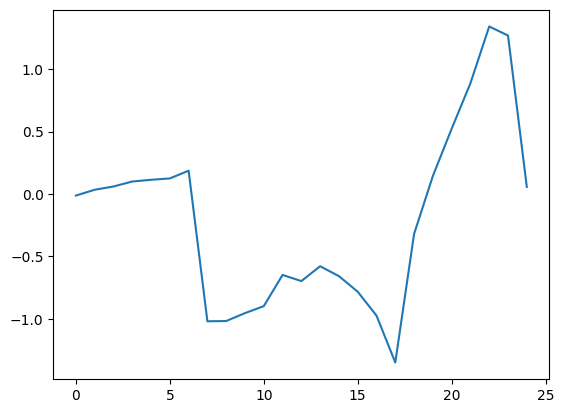

Layers: 25
torch.Size([1, 25, 2880])
[-0.01857950410826338, 0.021387536790635726, 0.047760016653272765, 0.061457924948798294, 0.06308313073052259, 0.12431486087375304, 0.16711200205485102, -0.4066918046739277, -0.38278348202175044, -0.3086588711208764, -0.2878038770887518, -0.08944179450140474, -0.058585025363498376, -0.060810628255208166, -0.13335529581706454, -0.26700269911023855, -0.4924605645073822, -0.5917397460937623, -0.5985346272786441, -0.036186781141498606, 0.43602095540364505, 0.9445252549913349, 0.24584265136716685, 0.4958085530598786, 0.04830366124047245]


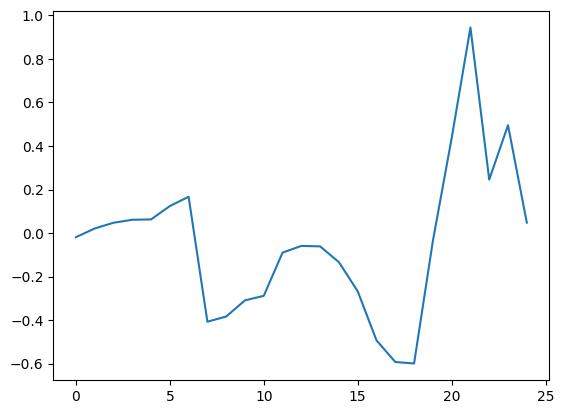

Layers: 25
torch.Size([1, 16, 2880])
[-0.012467481416630935, 0.037636099755763874, 0.0739892184734347, 0.10624107023080227, 0.11952014631695146, 0.16737573809094025, 0.23956673873795498, -0.6444511837429353, -0.618091275956894, -0.5476057741377054, -0.549890237384366, -0.31813537809585235, -0.3956860012478285, -0.31608331468371, -0.37412307527328803, -0.3625085777706601, -0.37036014133028644, -0.6877020941840258, -0.04795102013481992, 0.44119495815700116, 0.6909159342447813, 0.2115171856350351, 0.35740089416503873, -0.22467341952853218, 0.026379133098655583]


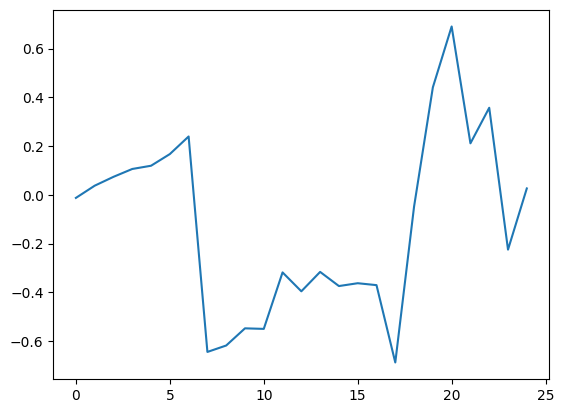

Layers: 25
torch.Size([1, 20, 2880])
[-0.008211682587344659, 0.042263498504956344, 0.07701491766505802, 0.12264643086327527, 0.16702033148871717, 0.2260369777679444, 0.2716966586642806, -0.4037534475326524, -0.3770767148335719, -0.2580548530154675, -0.25897201961940647, -0.07677906460232534, -0.13670356750488194, -0.07285277472601163, -0.1794596523708718, -0.29687160915798216, -0.6025979868571057, -1.0102582634819792, -0.5538408406575489, -0.45713019476996086, 0.12824032253689258, 0.7766507975260469, 1.760701666937938, 1.920557657877562, 0.07760347154405339]


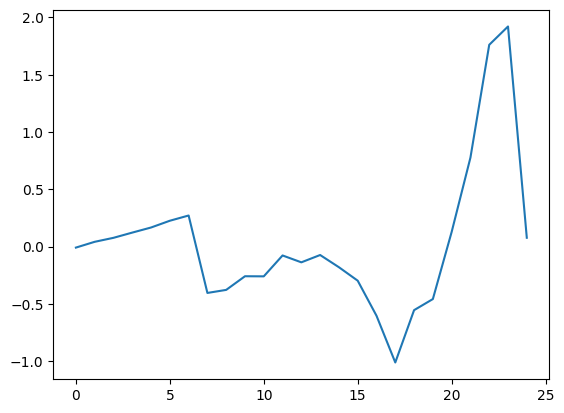

Layers: 25
torch.Size([1, 19, 2880])
[-0.01972892782977682, 0.020240087746179428, 0.05241768206769199, 0.08152968534949305, 0.08942705232497591, 0.12653278997767162, 0.1604002166212648, -0.6118579909118299, -0.6136443891023359, -0.5627574898346311, -0.5726569370916634, -0.4165071275499197, -0.46853016189663843, -0.3721127471031481, -0.49229792544716594, -0.5973302830032396, -0.7702423809564768, -1.190419907597777, -0.6252830996150828, -0.20552339609603307, 0.0925313135336738, 0.6092799850374618, 1.0208480031866678, 0.8155652854874746, 0.03945908114226923]


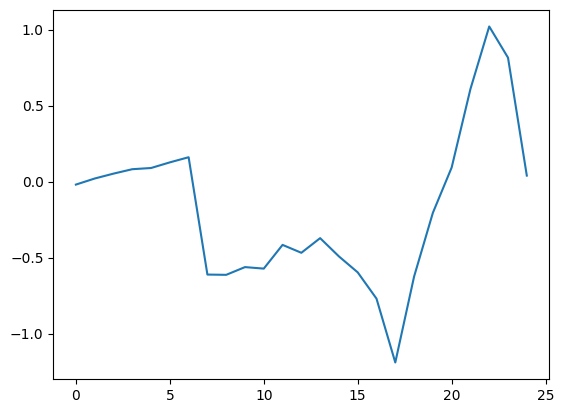

Layers: 25
torch.Size([1, 17, 2880])
[-0.0186451354351659, 0.016134282031090217, 0.056779072019788844, 0.061810706020181225, 0.07630314421809568, 0.1280666251587712, 0.17430202758389857, -0.659173080344593, -0.6327616722755183, -0.5907468459185399, -0.5543273526858661, -0.360262333489707, -0.5251123565474328, -0.4015476501065943, -0.33371837341707056, -0.24650244619332265, -0.465281178592858, -0.8507737303091776, -0.4306555754219021, -0.42047930948095324, -0.18942224839153593, 0.055345123889398745, -0.37581184736263623, -0.9438482945261479, 0.011134522413116871]


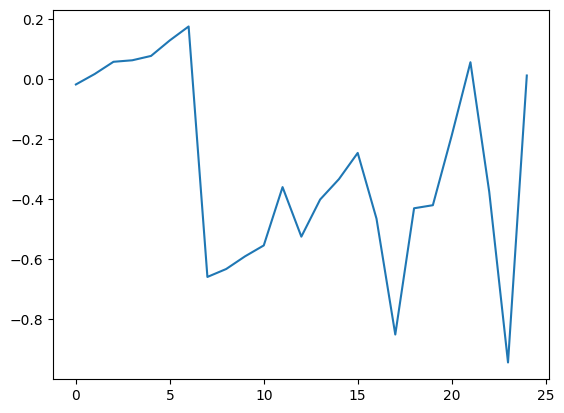

Layers: 25
torch.Size([1, 24, 2880])
[-0.01987361331735469, 0.027759363695427062, 0.05844404333167613, 0.07706613364043204, 0.08210752010345375, 0.13351535267299994, 0.14893524735062114, -0.45800426977651826, -0.45290342613501283, -0.412055594832814, -0.5132136150642743, -0.3523363395973492, -0.456294307002322, -0.278766589694556, -0.35817240255850535, -0.3853947462858782, -0.6735285229153172, -1.1047933083993355, -0.5940033382839699, -0.5237545084070322, -0.5379595014784079, -0.2822619967990433, -0.6883369728370876, -1.4723835415310327, 0.015401719124228807]


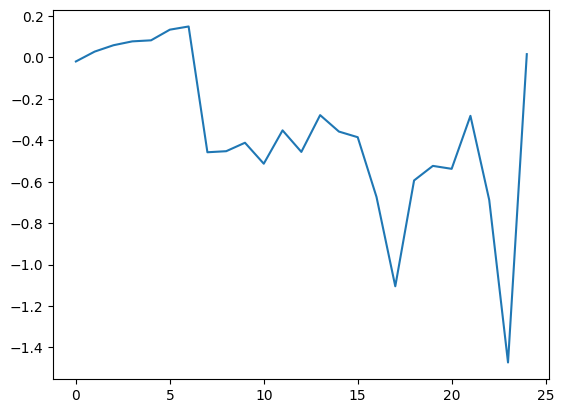

Layers: 25
torch.Size([1, 18, 2880])
[-0.0265468848475405, 0.01979792589022787, 0.04969869013185856, 0.0822924731690212, 0.09924987157185872, 0.13419875509944862, 0.17100549038545634, -0.6324806613686782, -0.6388759189181904, -0.59208397453215, -0.5338189301667581, -0.3551645632143481, -0.3992186369719287, -0.1985219508041567, -0.2567863370165346, -0.3972283539948564, -0.5122877332899296, -0.8346874660915757, -0.08300981403868822, 0.4294741783613069, 0.6665636980975068, 1.0900127457983808, 1.4682610500005915, 1.6455769103250333, 0.06558660011232632]


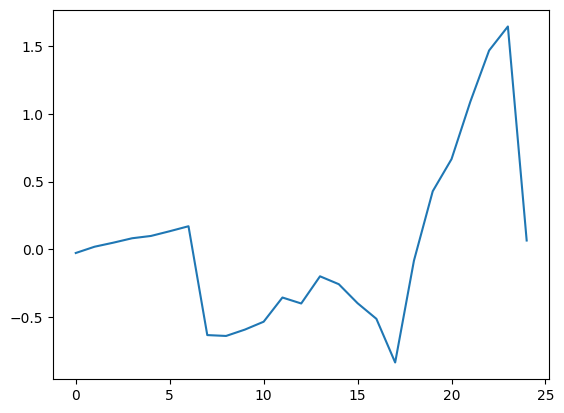

Layers: 25
torch.Size([1, 11, 2880])
[0.013252197640402391, 0.06538099616464933, 0.11368059823007297, 0.15551830927531052, 0.17148395692459314, 0.25352140099111187, 0.31852364010281, -0.9861646825617132, -0.92998343766337, -0.8151297366980341, -0.8281034758596628, -0.47753409954032394, -0.4734264181117863, -0.2935350976809135, -0.23483741066673738, -0.13135983245540941, -0.3837724781999696, -0.7521761345140712, 0.48011859932331113, 0.69269785254893, 1.11082350605667, 1.479096476236969, 0.7846796209161973, 0.3195266877762064, 0.051285413539770834]


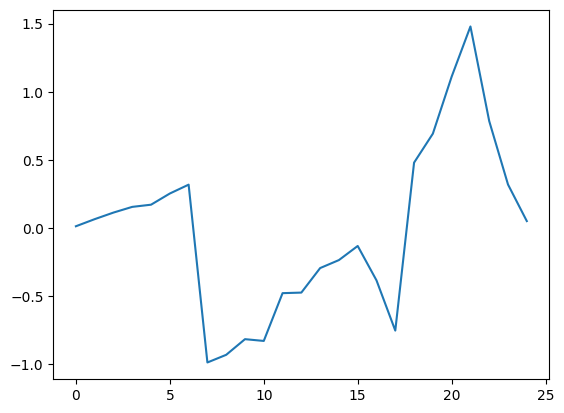

Layers: 25
torch.Size([1, 18, 2880])
[0.006501661890968245, 0.0540737784939045, 0.08581350026307241, 0.12988362371185647, 0.13912352809199732, 0.19941947254133865, 0.2118361084549515, -0.553961959885968, -0.5463754630383069, -0.44487873124488664, -0.443480136070731, -0.2132237940658872, -0.2084039570372719, -0.14377622722108818, -0.19635619646237473, -0.26897145024053526, -0.5187082172911842, -0.8885144457404909, -0.37560893871166023, -0.2116765528549395, -0.16294875910252787, 0.41341036572868356, 0.027685283142846514, 0.005216094593941798, 0.04487853138535151]


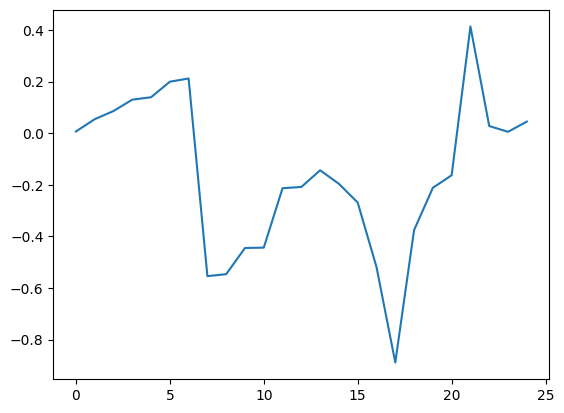

Layers: 25
torch.Size([1, 12, 2880])
[-0.014584225775561947, 0.024253416061401457, 0.055893522721749925, 0.0815572438416656, 0.10280541314019057, 0.14372110410972838, 0.20122453901502738, -0.9942590572215837, -0.9696279243186624, -0.8939698360584377, -0.8383667981183087, -0.6241920753761475, -0.6799435650860751, -0.5703156365288758, -0.4584833498354379, -0.4968259316903578, -0.6451487505877406, -0.927877016420725, 0.17216528433340642, 0.41645338270399096, 0.5421839396158857, 0.76281919126157, -0.05143619113497892, -0.7885285554108837, 0.0071812961940410916]


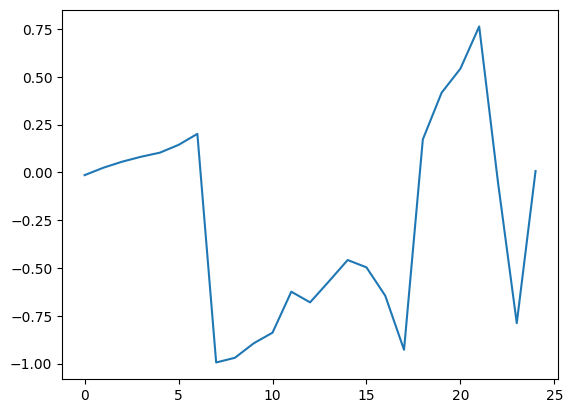

Layers: 25
torch.Size([1, 15, 2880])
[-0.0019129792245587203, 0.036366279743335804, 0.06337710168626569, 0.09354932785034195, 0.08634305176911589, 0.13224253619158732, 0.18173095420554947, -0.777490474559644, -0.7455106155960673, -0.6776394540292101, -0.6258493126763295, -0.36538180315935886, -0.41992377387152213, -0.31511030409071544, -0.3760319349500923, -0.5006061695240162, -0.537357742874713, -0.6972700387460277, 0.10874050564236067, 0.6957488561559613, 1.1208093713830993, 1.0840740288628528, 1.4640288628472244, 1.8739080358434221, 0.06813003398754029]


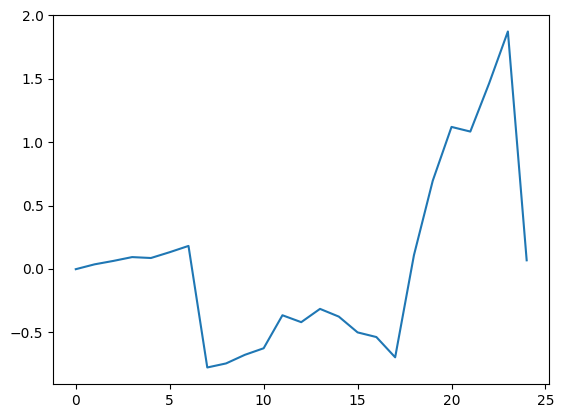

Layers: 25
torch.Size([1, 31, 2880])
[-0.012047550824093568, 0.03765884454105052, 0.06503210648840958, 0.09484663436916996, 0.11423025062861814, 0.13579655992514883, 0.16077130430488348, -0.25292334607851524, -0.28048430001864305, -0.20938875478655733, -0.1090613197682083, -0.04690564883652494, -0.07824582882678649, -0.06604215560421042, -0.054344992142000476, -0.19815013160842163, -0.377873249122317, -0.7595381842719126, -0.15183530417821725, 0.14469969828069232, -0.06923448569458435, 0.47493711628794066, -0.16728000435777843, -0.13448991672966995, 0.03206587662406298]


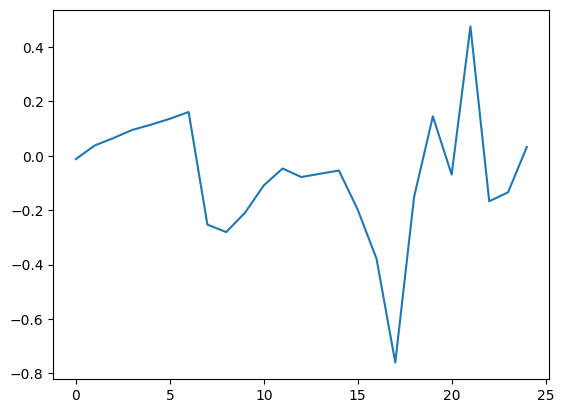

Layers: 25
torch.Size([1, 18, 2880])
[-0.006636903173560396, 0.03933280706405638, 0.06731623013814217, 0.10415561522966565, 0.09746751314328066, 0.15915021896362225, 0.18189525251035352, -0.6137597449031912, -0.5604916089846808, -0.5054163591361387, -0.5317817617345637, -0.3440206080307075, -0.30882503368236397, -0.21317012457198645, -0.330335960859139, -0.4567455903983403, -0.659421077775349, -0.8281802330488025, -0.3490063890998738, -0.23352476520302917, 0.06968413929880458, 0.5529913819866391, 0.6028664671344395, -0.16067911783854713, 0.03040718513506419]


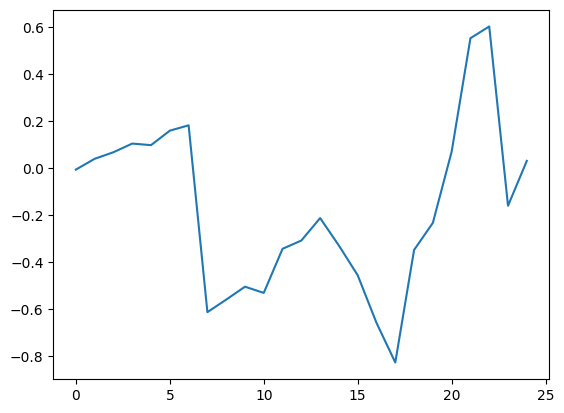

Layers: 25
torch.Size([1, 13, 2880])
[-0.01848390480149218, 0.024201960033840876, 0.06283541703835527, 0.08701222411587668, 0.1133928510877824, 0.17144428481403604, 0.2333693316859055, -0.8860589198577047, -0.8224942362206474, -0.7270208798922014, -0.7096825363289654, -0.4467387924846496, -0.4848837828024964, -0.4603177258092106, -0.4713448157677131, -0.5358091957548793, -0.6801173544337613, -0.8023894350752865, 0.5381561540130875, 0.8709931202423815, 1.7053910736344966, 2.668144917284295, 3.785208573300595, 3.841038161057726, 0.10610219892273645]


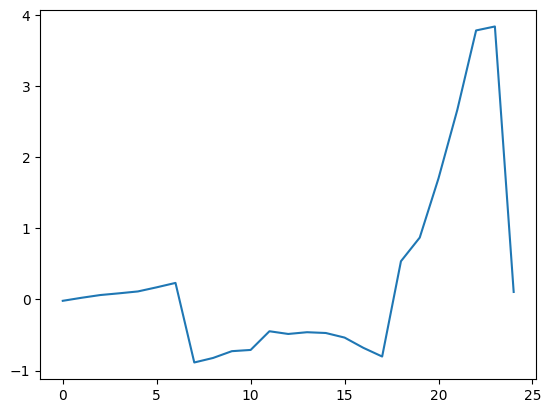

Layers: 25
torch.Size([1, 11, 2880])
[-0.013946662240219475, 0.03617618637855609, 0.0737596232481669, 0.10589454727943565, 0.1258369551764595, 0.17945680329293975, 0.23577496307064896, -1.065946328519585, -1.0541941662027294, -1.0269963582356754, -1.0294907386856917, -0.7652749880395652, -0.8217455931384116, -0.7874608203618159, -0.7734764022056452, -0.7433009600398502, -0.8153736153034329, -1.1210061275597758, 0.4489506422871305, 0.8960805873678183, 0.9444687968552725, 1.2174409500276255, 0.8725044635811244, -0.08654760495580885, 0.023208927024494157]


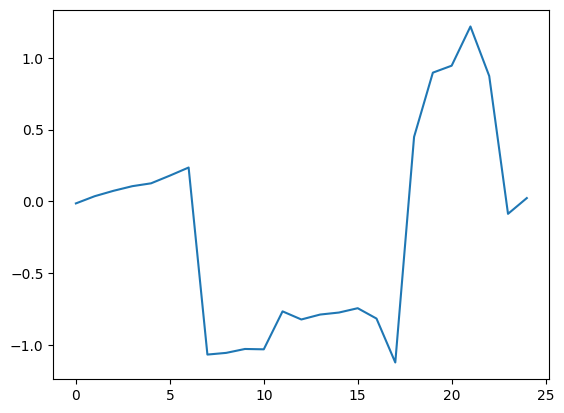

Layers: 25
torch.Size([1, 14, 2880])
[-0.027550035883905564, 0.01017025349632138, 0.026579535196697902, 0.06845785549708752, 0.07462986386011507, 0.09512852714175253, 0.13833959670293972, -0.8952559879848012, -0.8711466895209428, -0.8137429191952614, -0.9030488392663428, -0.7302715119861486, -0.8454608614482549, -0.8469257839142322, -0.9040911114405049, -1.0141212221176044, -1.106959012954944, -1.3501425606863753, -0.2715851314484118, 0.3641209678044354, 0.8480007111080178, 1.5978361099485279, 1.9891524057539711, 0.9675737411256788, 0.06214053838972103]


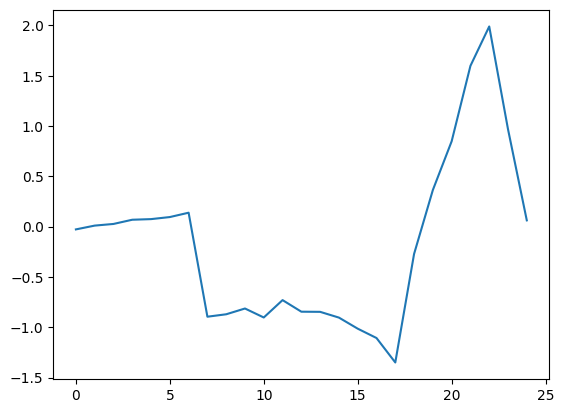

Layers: 25
torch.Size([1, 11, 2880])
[-0.01569126125856081, 0.03600037940824889, 0.060452737711896916, 0.09455984481657388, 0.11493697118277538, 0.17126195310342218, 0.16774350175953753, -1.1543475295557961, -1.1384013975509506, -1.097482268978846, -1.1266998599274074, -0.9189385308159694, -0.8827530369614135, -0.7318775832051115, -0.8081315397012104, -0.8836189655342477, -1.0664025200737839, -1.4780420476740117, -0.46315356938525915, -0.10972515067668742, -0.07917298596314595, -0.043508941958647414, 0.7333107071693596, 1.0350372622711415, 0.0613888903097674]


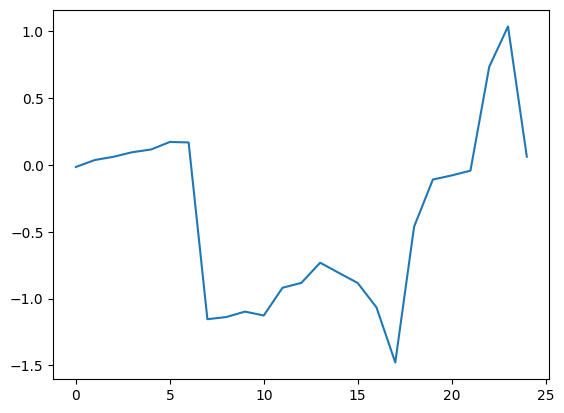

Layers: 25
torch.Size([1, 19, 2880])
[0.002623143003523722, 0.04965354852509054, 0.06819969060128149, 0.11355194097373808, 0.13146487118905, 0.20059614571911338, 0.27315755364490507, -0.47811082650346653, -0.4098451000905167, -0.33997741163822287, -0.34287589446842953, -0.08132051166735066, -0.13773794341506265, -0.04104039599322559, -0.14230317232901732, -0.32105707982827136, -0.46852314374600135, -0.9571845695986285, -0.3757522315309768, -0.09397217153805822, 0.0765569541886523, 0.6829474733586894, 0.7755053023845889, 0.9008702685261115, 0.05887661510043802]


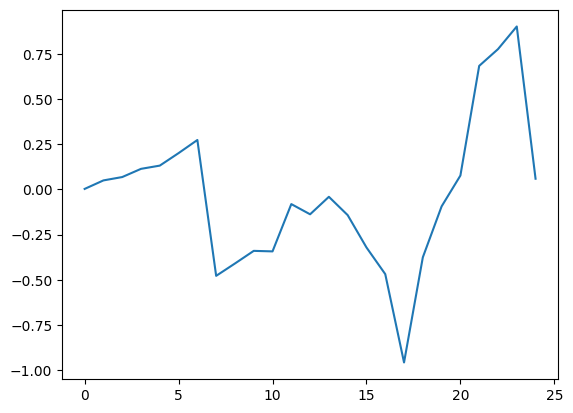

Layers: 25
torch.Size([1, 13, 2880])
[-0.0020196452900034904, 0.04778961157187427, 0.08511236793974512, 0.12900858495989437, 0.13722443050808325, 0.21356682247585812, 0.27890503712189596, -0.7998323326436747, -0.7684085291674967, -0.7252109690609122, -0.6553298884986877, -0.5059065989959028, -0.5755980923644616, -0.46460372403136746, -0.3804550301315447, -0.29267737233739904, -0.26796629816038753, -0.5690178504356724, 0.4576641767452891, 0.6423740093524695, 0.637866002270296, 0.5907724755441949, 0.12505143646501002, -0.9804746970152186, 0.019334155168288875]


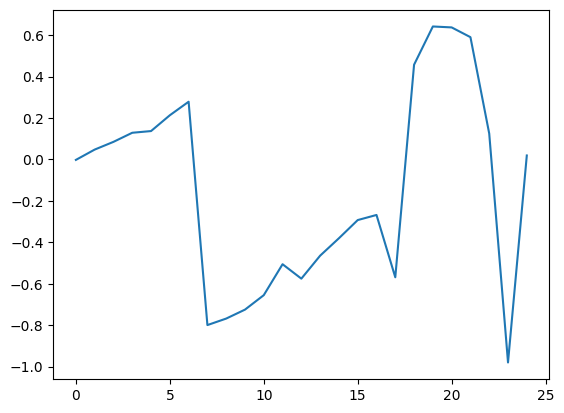

Layers: 25
torch.Size([1, 24, 2880])
[-0.015612671549940851, 0.03043084100440713, 0.061226844566839383, 0.09136044272670105, 0.10440036720699836, 0.12701404536211877, 0.14408079429908974, -0.4303038703070806, -0.4326960334071639, -0.35589919796697744, -0.3748366249932127, -0.25956902857179687, -0.341290043018484, -0.23688092055143942, -0.35500694557472257, -0.4653748053091517, -0.8126143632111471, -1.248124073169838, -0.7281396371346897, -0.4302246800175438, -0.29374569080494206, -0.43856896294488656, -0.3040018399556479, -1.0604269239637518, -0.004582492786425017]


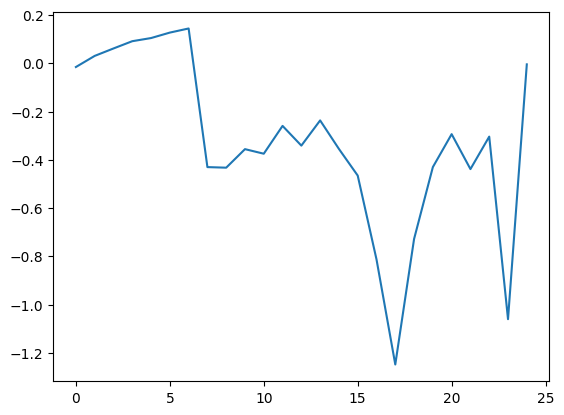

Layers: 25
torch.Size([1, 15, 2880])
[-0.008457401752195984, 0.03777394082811129, 0.08340953049836324, 0.09466125382317421, 0.13558049943712003, 0.1822009941383638, 0.23810427135891338, -0.7343669495759174, -0.6988105632640589, -0.5975847032335018, -0.539580982349536, -0.34428249217845586, -0.42488146746600536, -0.3233037990993979, -0.38976220590097976, -0.3472054036458256, -0.5078481490523776, -0.776234345612714, 0.06739694100839033, 0.632542498553242, 0.9673603877314856, 0.9967580159505205, 1.0405592628761526, 0.6102798574942169, 0.034342593992197815]


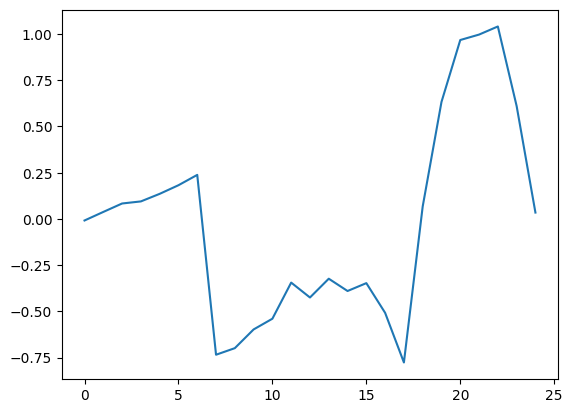

Layers: 25
torch.Size([1, 18, 2880])
[-0.007939846412980083, 0.04046041347362428, 0.09294866455925897, 0.13005313402340857, 0.1544770229009939, 0.21107411443451302, 0.24598511118947877, -0.5347579744127124, -0.5364969559657587, -0.45429318510454514, -0.4322899618266441, -0.12735332441919164, -0.19624160013080766, -0.02968624256275066, -0.0456342155550738, -0.25907406277126077, -0.37424866476176594, -0.6118220388153485, 0.24302265025951614, 0.48633475597993286, 0.2648696899414052, 1.280081666546094, 0.5823002567997645, 0.8499698215060814, 0.05479436406382804]


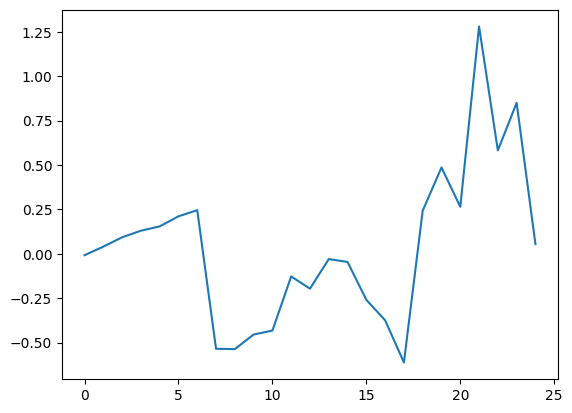

Layers: 25
torch.Size([1, 7, 2880])
[-0.011721287410528861, 0.02723189384218263, 0.07581621200319333, 0.10769299401177265, 0.1102278436933242, 0.17431545560322106, 0.21917192973787836, -1.8149137951078946, -1.7872405158148794, -1.7364420815119808, -1.6817693801153277, -1.438901362343433, -1.3952035570901447, -1.2951439993721987, -1.272253805493555, -1.3770822191995458, -1.6582155257936568, -2.12147081163195, -0.33317800854879787, 0.049952721974205375, 0.20729234483507242, 0.7495256696428503, 1.0842944917224648, 1.5703358483692906, 0.04860744400629963]


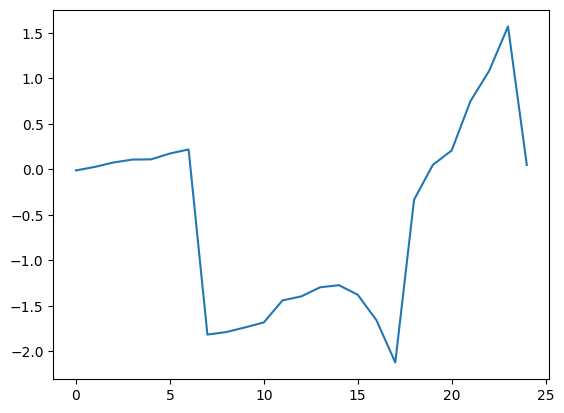

Layers: 25
torch.Size([1, 17, 2880])
[-0.01690174100534021, 0.029557376009186877, 0.0563487702724977, 0.09522409688413586, 0.10815278844895597, 0.14765362739562912, 0.18834468866485252, -0.6185726514828691, -0.6166616527083559, -0.5604127347858848, -0.46677412643931043, -0.24665499419167483, -0.16686450235205044, 0.025890408933550716, 0.057125944249760925, -0.032516918307038886, -0.15785674051520526, -0.322356579350491, 0.20230712890624863, 0.4948079826005879, 0.08118078693066158, -0.023157177096096576, -0.10673684512868013, -1.1803079841962871, 0.005449918750064772]


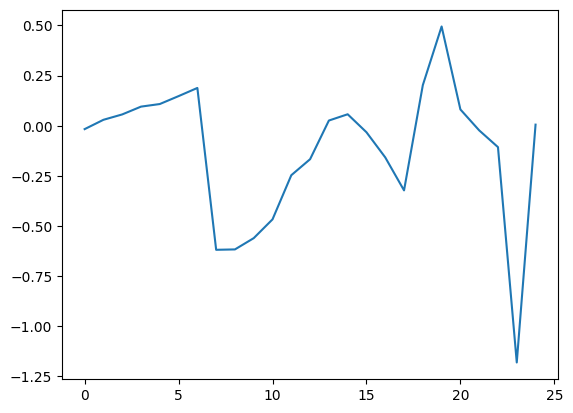

Layers: 25
torch.Size([1, 20, 2880])
[-0.024153125024943878, 0.022553798622555313, 0.05695798714955694, 0.09755695554945099, 0.10355359554290632, 0.1734174283345547, 0.20460378011067729, -0.49919917212592285, -0.453990234798857, -0.35643430497910594, -0.3526266988118403, -0.17273882548014, -0.24554924858941915, 0.006096594068737421, -0.05206720564100927, -0.08595575120714019, -0.12427667405870883, -0.4237470669216674, -0.02273330688476528, 0.13091832478841145, 0.45323961046006495, 0.8528817749023418, 1.3479113430447076, 1.1684513346354277, 0.04770080592897177]


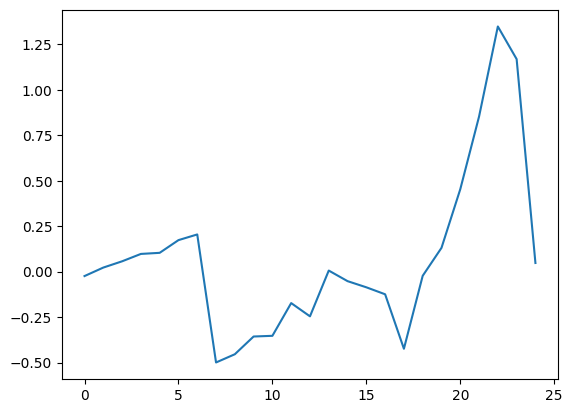

Layers: 25
torch.Size([1, 14, 2880])
[-0.004394521039452321, 0.035428495823390686, 0.04844309602464918, 0.07932174281468474, 0.07760750604054344, 0.1201782218993656, 0.1700179675268743, -0.844216069721043, -0.8147981007893964, -0.7701335362025716, -0.7829777914380338, -0.5761287719484267, -0.5867684621659505, -0.45928187900119044, -0.4566820280892551, -0.49866208273267076, -0.6384130326528323, -1.0983139976622498, -0.22213937668572872, 0.28369566902281723, 0.12631099640376503, 0.3596267942398307, 0.1279929993644611, 0.23662254696801055, 0.02944258645413438]


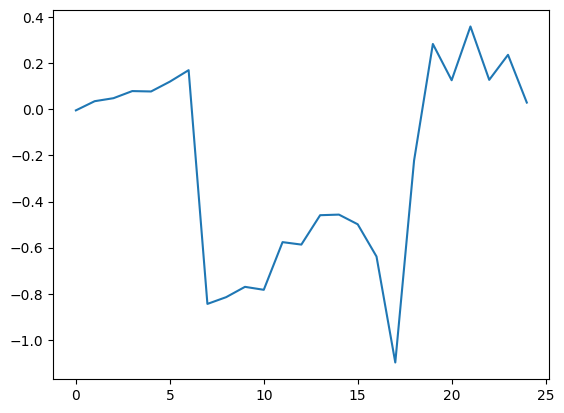

Layers: 25
torch.Size([1, 13, 2880])
[-0.012510222577067971, 0.024771224127875427, 0.06308210364773775, 0.07788791248940999, 0.10282080071604202, 0.1142721441056998, 0.14150153266059062, -0.9579592941153741, -0.9399664984809123, -0.8965251303126495, -0.8870442838750373, -0.7816439375918046, -0.9014955439119257, -0.8888419387686946, -0.8173799954928068, -0.9058596097505699, -0.9990309364775413, -1.108191061427448, 0.1629552792280155, 1.199450579260144, 2.028963816064051, 2.8622605543870154, 3.395585514948949, 3.7934784196380718, 0.10419369844289957]


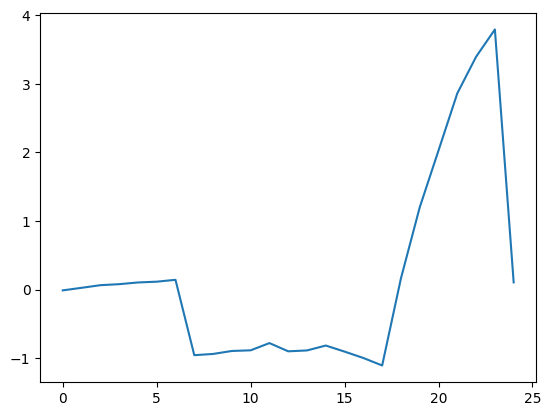

Layers: 25
torch.Size([1, 10, 2880])
[-0.0263660289849052, 0.015421562724643297, 0.04149933973948184, 0.07140154202779138, 0.08102048238118453, 0.12186978446112726, 0.1719459131028914, -1.3020833841959876, -1.2948868560790836, -1.2237851164076141, -1.2616929817199773, -1.0235839589436602, -1.1088271755642565, -1.0167026774088388, -1.1113946194119102, -1.2946414862738738, -1.4471132405598945, -1.9093674045139024, -0.5068016730414551, -0.07491421169704847, 0.6264122856987803, 0.9594370524088485, 1.6331774902343654, 1.4863315836588504, 0.03604850477642493]


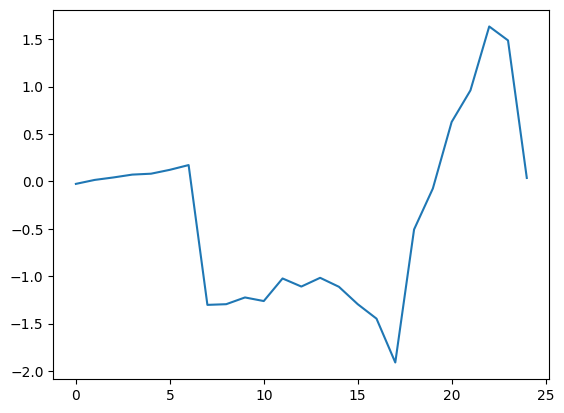

Layers: 25
torch.Size([1, 14, 2880])
[-0.005862243682153432, 0.0431189656257633, 0.06485350945639269, 0.1043962194806048, 0.13538476247636158, 0.19717932352944062, 0.2121098904382601, -0.7951904962933096, -0.7488700321742139, -0.6347870145525054, -0.7053496466742641, -0.45881128462533277, -0.3970227075001663, -0.32149934920053996, -0.32422443571545634, -0.23606980944436823, -0.45840923975384845, -0.5881263369605767, 0.20369253007192636, 0.8877570742652497, 0.9827641320607209, 0.8168659149654274, 0.07764102996341304, 0.19160020616319234, 0.041621527974567425]


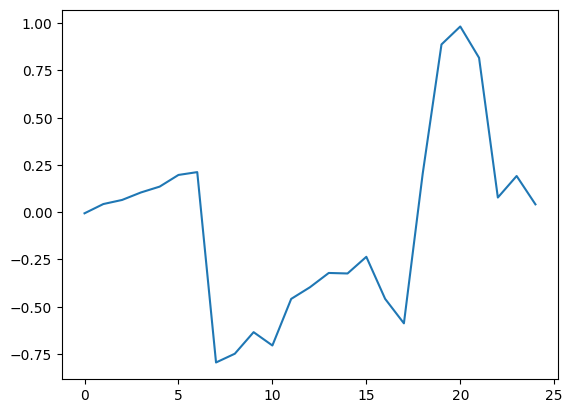

Layers: 25
torch.Size([1, 18, 2880])
[-0.025793613365098136, 0.008195000813331133, 0.026459936521671074, 0.056041752261879976, 0.05290464089240559, 0.08929362532533332, 0.0954521273389269, -0.713786436010282, -0.6974609563380082, -0.6461754928400408, -0.6445719212661503, -0.5224839151641445, -0.6509246496506579, -0.654909242229683, -0.7582891205210877, -1.0031054273063862, -1.2740373399522626, -1.6670510280279565, -1.0741644965277783, -0.8826460850091619, -1.249906036000194, -1.4727259506413957, -1.9827662715205585, -2.027997730396398, -0.03301869233449295]


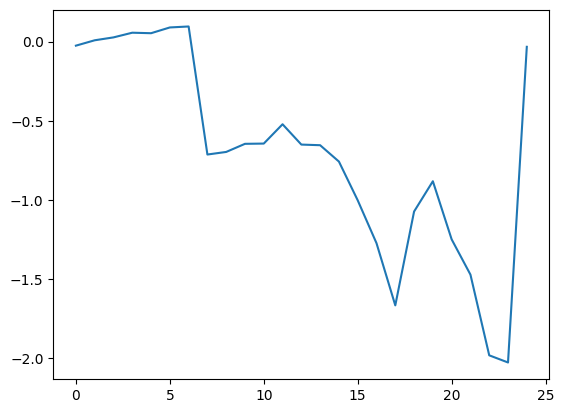

Layers: 25
torch.Size([1, 14, 2880])
[-0.01803817971173452, 0.03179584949735622, 0.051405784818861495, 0.06587868550467135, 0.06893851416451598, 0.12295737796359671, 0.16984475756448414, -0.890606203533339, -0.8467374619983482, -0.7813066815572955, -0.8772196209619906, -0.6933048127189536, -0.8586481851244687, -0.7459345984080445, -0.8349622544788278, -0.9378296988351028, -1.182035282679975, -1.409074135432139, -0.4948487539139964, -0.25334138416108726, -0.3812521313864083, -0.11917937748016386, -0.5848758273654466, -1.2504129076760928, -0.023241612173262004]


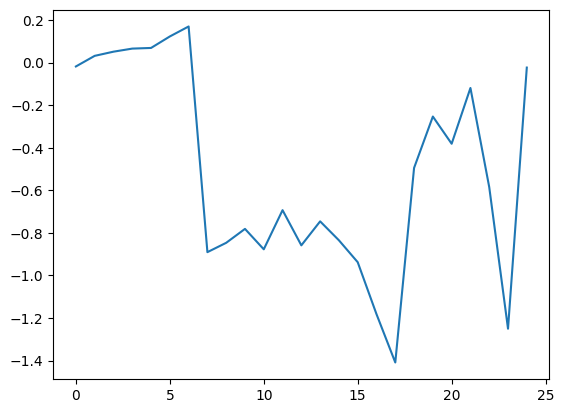

Layers: 25
torch.Size([1, 12, 2880])
[-0.023255968714322603, 0.020843006946422493, 0.02907894275806578, 0.059704739959151626, 0.06806912687089703, 0.09907854751304368, 0.15466618714509092, -1.056822222250486, -1.0524519885027945, -1.0213023927476672, -1.104979776453097, -1.005167558458122, -1.1375079049004435, -1.1582524052372922, -1.4678839224356417, -1.556386848732264, -1.7019231866906936, -2.4166950367115088, -1.6676128246166038, -1.73479196053964, -2.4374157940899743, -2.671695228859236, -2.8712606359410984, -2.6530819363064237, -0.027269893222384933]


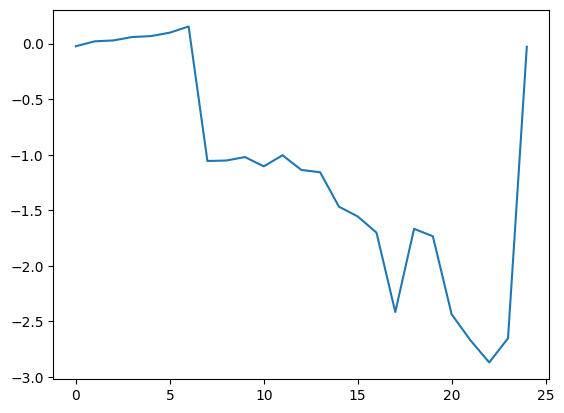

Layers: 25
torch.Size([1, 9, 2880])
[-0.02459847638124797, 0.025322229479566076, 0.05570517174991559, 0.07267350444087281, 0.09569384256998699, 0.108555365786141, 0.1600953749668456, -1.4631308190616492, -1.4527502271864245, -1.422033766758323, -1.4099792292088653, -1.1816428290473067, -1.2634809329186032, -1.1610620569299863, -1.184252948525525, -1.2796165372118506, -1.3894873442473177, -1.7745050124180157, -0.16481436270254568, 0.3212679262514415, 0.5518189606843187, 0.40519959249613985, 0.2668063316816218, -0.07409170645254312, 0.016831868224673953]


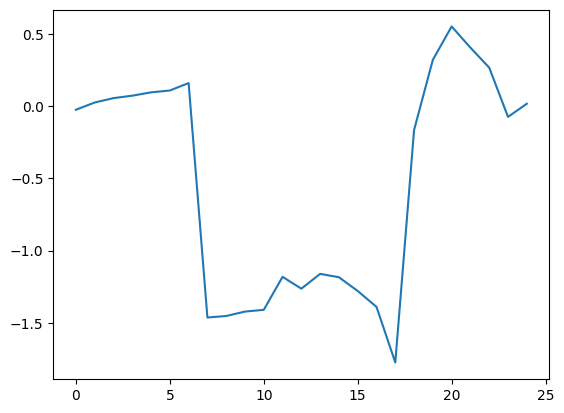

Layers: 25
torch.Size([1, 11, 2880])
[-0.012725144695735137, 0.024325125145189704, 0.04233450070776107, 0.07257138839875855, 0.09634565488256606, 0.1480924644855536, 0.17055314189255907, -1.1437787797715815, -1.158651099542181, -1.1295819831616782, -1.1684799964981707, -1.0390192051126454, -1.1978301231307062, -1.1627761763755804, -1.45657683093139, -1.596442868011144, -1.8809841117473631, -2.284083264283445, -1.3678147441208852, -1.127961499763253, -1.1411853520557196, -0.5935233067984504, -0.2133230190084404, -0.37473853525489603, 0.0075226387592277144]


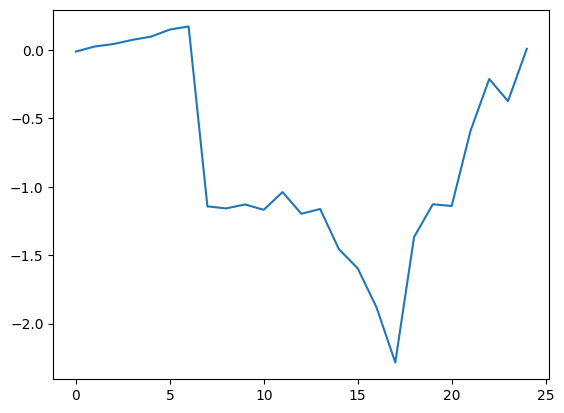

Layers: 25
torch.Size([1, 19, 2880])
[-0.02088823318563138, 0.027155102344981516, 0.06568482716878205, 0.10900128236290998, 0.12128985109385049, 0.18263031139708397, 0.2244245551482991, -0.512338389569548, -0.4790341237832216, -0.43811680977803785, -0.48812787240011907, -0.3166453445166955, -0.377146612691611, -0.2247374060558344, -0.36858062744140563, -0.4984887998703752, -0.6167497422959998, -1.0881946853726825, -0.23600658840602617, 0.5936841462787859, 1.0913718954164318, 1.7264684844435225, 1.921938854909059, 2.4627292209201155, 0.07442027710334623]


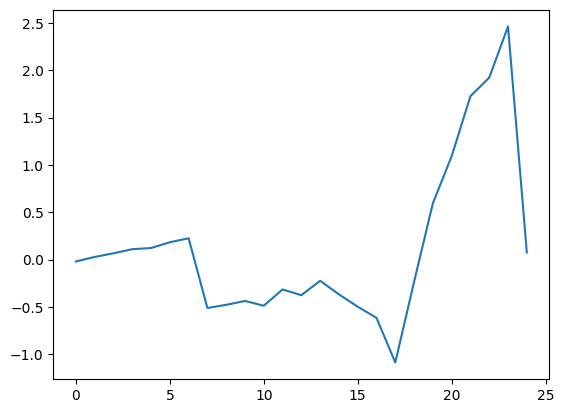

Layers: 25
torch.Size([1, 15, 2880])
[-0.010025105786992722, 0.02975013309054908, 0.06821790200692569, 0.11031789497092916, 0.11564895771167788, 0.1539610530711983, 0.20012909783257452, -0.7393357510036864, -0.7286145471643549, -0.7044560411241471, -0.6618218655056346, -0.4529639858669811, -0.5316703061704213, -0.44374700475623247, -0.5006011849862562, -0.43878199824579545, -0.5644561654550009, -1.0027817111545076, -0.4551579058611846, 0.5134681306061927, 0.7370226598668894, 1.0104509932906485, 1.414074254918994, 1.7924266673900437, 0.05451954382437229]


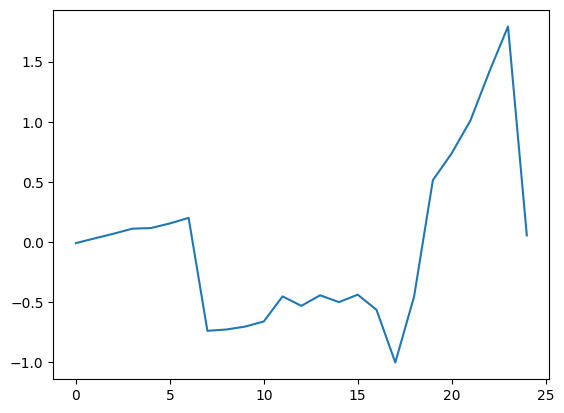

Layers: 25
torch.Size([1, 18, 2880])
[-0.025612608491109832, 0.017023021497843932, 0.04437424282968791, 0.08629049725002687, 0.10756485550491882, 0.14736937299186825, 0.16126745600759104, -0.6328060314979019, -0.6124211723421754, -0.5576918331193293, -0.6122428564377765, -0.42229355235159494, -0.536303776870537, -0.4268900176625218, -0.5059847702214634, -0.6907086784456914, -0.8764404202684939, -1.0423294444142919, -0.42276296733338, 0.21021351755401452, 0.55894696270978, 0.9083970058111435, 1.5481463773750848, 1.925482309600439, 0.0627664279054711]


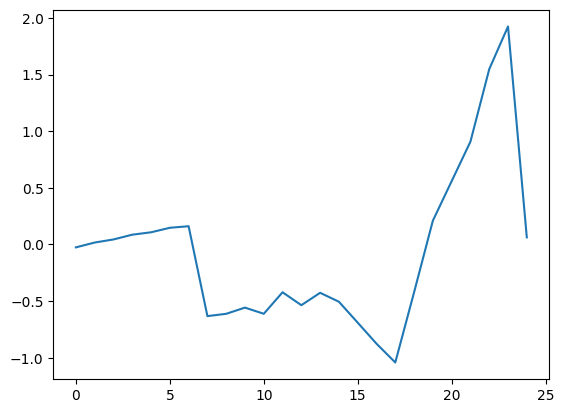

Layers: 25
torch.Size([1, 12, 2880])
[-0.029396253711483567, 0.019742168320549924, 0.062070249628137536, 0.1033886768199777, 0.12937406080740463, 0.17906135982937235, 0.2419934731942627, -0.9667198816935237, -0.9313962300618228, -0.8412204848395445, -0.8190054293032138, -0.5860656173140838, -0.6424241878368385, -0.497799470689548, -0.5082552097461892, -0.440760661937566, -0.6003497088397055, -0.9143742314091456, -0.07243731463396842, 0.07597303037290001, 0.7228667365180174, 1.1187624896014141, 0.8523560135453001, -0.25145760995370786, 0.014755558967590583]


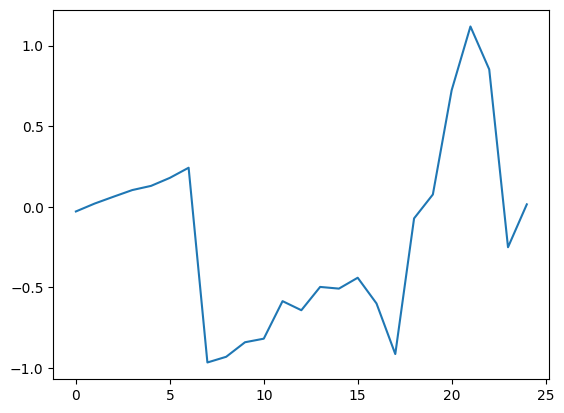

Layers: 25
torch.Size([1, 15, 2880])
[-0.024716254798695363, 0.02710228637412729, 0.03624427159627282, 0.06466503355238219, 0.07721143793176763, 0.12905024139969465, 0.17017921589038917, -0.7864460726137606, -0.7796847703721899, -0.7222701489483848, -0.7774360882794389, -0.6127130692093385, -0.6678181118435282, -0.6720947604709069, -0.83707951298466, -1.030161675347233, -1.3630695032190334, -1.8780468863028092, -0.9430516447844306, -0.6754419849537012, -0.545995415581599, -0.3099332230179427, -0.5466331199363405, -0.036985496238431684, 0.03944115444465939]


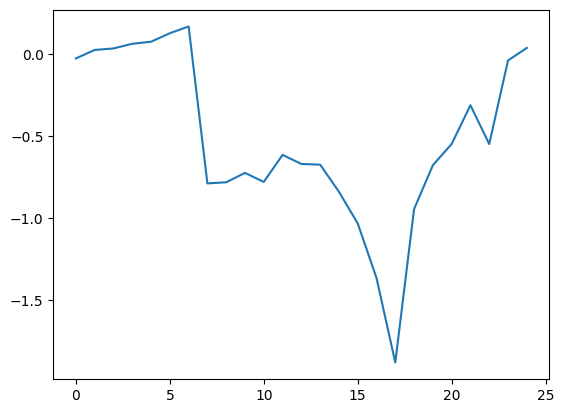

Layers: 25
torch.Size([1, 11, 2880])
[-0.005726305807404332, 0.04343030380480178, 0.08497125693041922, 0.1387703375382846, 0.1577760426685065, 0.21189306673377425, 0.2783488109858347, -0.994363172126538, -0.9978669060601213, -0.9300496111012504, -0.9015860355261712, -0.7049863102460127, -0.8898171627160463, -0.8217922634548637, -0.9059023770419021, -0.998826614534013, -1.0552856637973904, -1.2931604867029702, 0.16215869633838367, 0.7019262294576688, 0.8743694883404534, 1.4930758389559744, 1.7753040968769926, 1.1640794542100723, 0.06045396785543443]


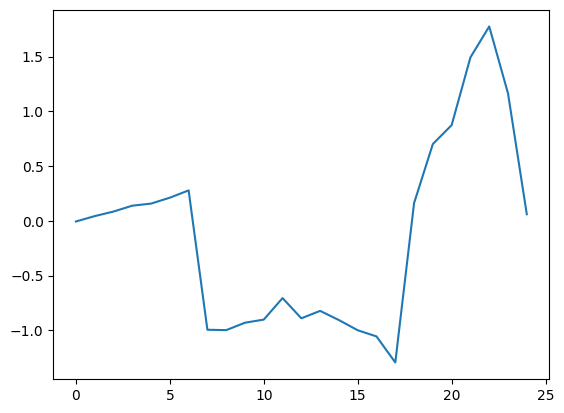

Layers: 25
torch.Size([1, 19, 2880])
[-0.005199362945263656, 0.039247844233150364, 0.07651603960851477, 0.1178511190135567, 0.12070318857828764, 0.17903814817729594, 0.2207894275062957, -0.5102028205380911, -0.4748872857344861, -0.4368993658768416, -0.4527262325175291, -0.3077208669562119, -0.3207287615502797, -0.21138582285384117, -0.17767555281432026, -0.13102736445198834, -0.33063364307782694, -0.5457716378552007, -0.2487064026949707, 0.11111039724963842, 0.7158039204558435, 0.4303293685466812, 0.2546222530610335, -0.28119738840915953, 0.022027099899381116]


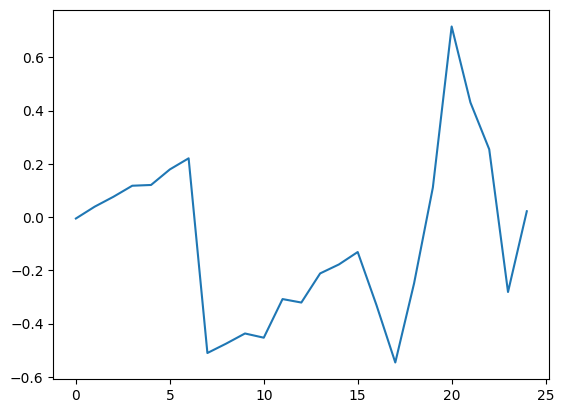

Layers: 25
torch.Size([1, 8, 2880])
[-0.021098047265938214, 0.036747291021876766, 0.08239303959740565, 0.13238015969594277, 0.16971592373318126, 0.24485396014319566, 0.2996647583113778, -1.4954915894402563, -1.4418011983235748, -1.3518699645995944, -1.290438954035436, -1.0328632778591549, -1.1117467244466306, -1.0755708058674986, -1.0032920095655347, -1.0603245841132218, -1.1239285045199803, -1.314175075954855, 0.7340081373850504, 1.474848259819894, 2.3425754970974246, 2.9388069152832133, 2.4518673366970614, 2.684856669108047, 0.08722752398914782]


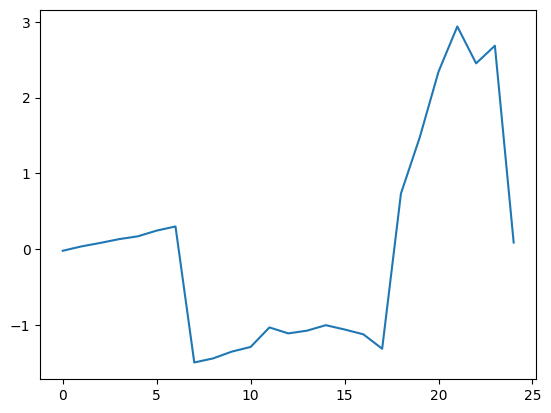

Layers: 25
torch.Size([1, 22, 2880])
[-0.02113165900033565, 0.011756520078639691, 0.03823651496810143, 0.06244143669051346, 0.0473472373654142, 0.08882763626599628, 0.10353338646166221, -0.5543143436162105, -0.5608752645627474, -0.5253031152667397, -0.5087289020268622, -0.3838746465817805, -0.5372174561625793, -0.5544381960473719, -0.6914673853402145, -0.8856127421061305, -1.0414978027344015, -1.2765791767775156, -0.7613146849352841, -0.9179856425584004, -0.5755332253196046, -0.5793645068852574, 0.12184516059027563, 1.0272516115747305, 0.057054305257218926]


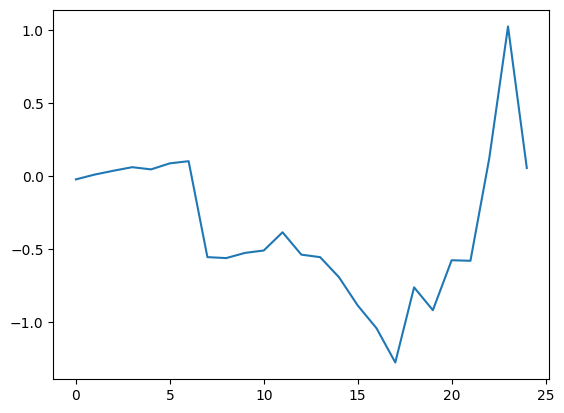

Layers: 25
torch.Size([1, 17, 2880])
[-0.01431406497714907, 0.038062926834704726, 0.06745765349444262, 0.10307927225150292, 0.10684003019644489, 0.13793608409906444, 0.15923329022974733, -0.6988680035460264, -0.678237615847126, -0.6119146758434871, -0.5877048816556382, -0.33969647276634685, -0.4344220628925496, -0.29352481817108583, -0.30758095535577124, -0.34488485498365695, -0.5985671797609148, -0.866300914490153, -0.2309659671160172, 0.016782932655483602, 0.18384276745366035, 1.0891482284645781, 0.8581967222924379, 0.5431311513863452, 0.042372992693209]


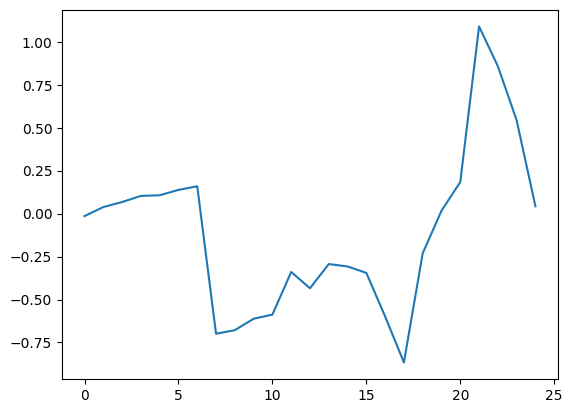

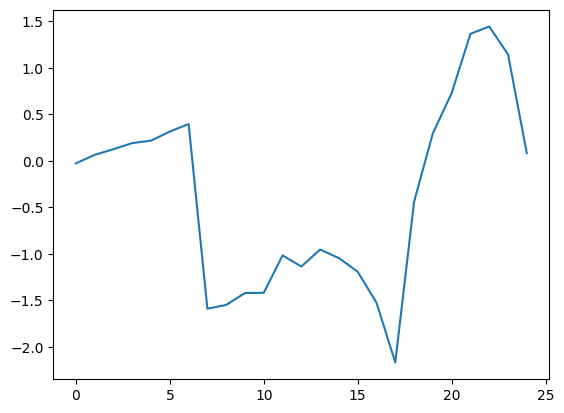

In [ ]:
with open("./prompts.json","r") as prompts_f:

    pf=json.load(prompts_f)

    layer_out_global_avg=[]

    for p_idx,prompt in enumerate(pf):

        text = prompt
        inputs = tokenizer(text, return_tensors="pt").to(device)

        outputs = model(**inputs)
        logits = outputs.logits  # shape: [batch, seq_len, vocab_size]

        # print(outputs.hidden_states)

        # un plot per layer
        # per ogni subplot: x->dimensioni per ogni token, y=token in input(parola)

        # Layer iniziali: token ancora legati a forma, vocabolario, sequenza
        # Layer medi: pattern semantici, relazioni tra token
        # Layer finali: rappresentazioni per la predizione del prossimo token 

        hidden_states=outputs.hidden_states

        #draw_per_layer_heatmap(hidden_states,"gpt_assess_plot")

        num_layers = len(hidden_states)

        print("Layers: "+str(num_layers))
        print(hidden_states[0].shape)

        layer_out_avg=[0] * len(hidden_states)

        if len(layer_out_global_avg)==0:
            layer_out_global_avg=[0]*len(hidden_states)

        for idx,hs in enumerate(hidden_states):
            for hs_dim in hs:
                for hs_channels in hs_dim:
                    for hs_tokens in hs_channels:
                        hs_tokens_cpu = hs_tokens.detach().to("cpu").item()
                        layer_out_avg[idx]+=hs_tokens_cpu/(len(hs)*len(hs_dim)*len(hs_channels))

        for el_idx,el in enumerate(layer_out_avg):
            layer_out_global_avg[el_idx]+=layer_out_avg[el_idx]/len(hidden_states)

        print(layer_out_avg)

        os.makedirs("./gpt_out",exist_ok=True)

        with open("./gpt_out/prompt_"+str(p_idx+1)+".json","w") as f:
            f.write(json.dumps(layer_out_avg))

        plt.xlabel("Layer")
        plt.ylabel("Mean Activation")
        plt.plot(range(len(hidden_states)),layer_out_avg)
        plt.savefig("./gpt_out/prompt_"+str(p_idx+1)+".png")
        plt.show()

with open("./gpt_out/global.json","w") as f:
    f.write(json.dumps(layer_out_global_avg))

plt.xlabel("Layer")
plt.ylabel("Mean Activation")
plt.plot(range(len(layer_out_global_avg)),layer_out_global_avg)
plt.savefig("./gpt_out/global.png")
plt.show()